# FoodOps.AI — DemandOps: Test Evaluation & Multi-Step Forecasting

This notebook evaluates our trained models and implements an **autoregressive multi-step roll-forward forecasting pipeline** for the out-of-sample test period (**weeks 146 to 155**).

---

### Core Objectives:
1. **Model Benchmark Evaluation:** Review the rigorous evaluation of all 4 architectures on the hold-out validation set (weeks 132–145) where true orders are known.
2. **The Autoregressive Challenge:** Resolve the multi-step dependency where `test.csv` (weeks 146–155) lag features (`lag_1`, `lag_2`, `lag_4`, `rolling_mean_4`) depend on values that haven't happened yet.
3. **Quality & Distribution Audits:** Validate that test predictions preserve the scale, variance, and seasonality of historical food demand without explosion or collapse.
4. **Final Submission:** Export `DemandOps/data/processed/submission_lgb.csv` ready for competition scoring and downstream operational planning.


In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import os
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("Environment successfully initialized.")


Environment successfully initialized.


## 1. Model Evaluation & Benchmark Scoreboard

In time-series forecasting, models are evaluated on a **temporal hold-out validation set** (weeks 132 to 145, the last 10% of historical data) to simulate real-world forward testing without future data leakage.

### Benchmark Metrics:
- **WAPE (Weighted Absolute Percentage Error):** $\frac{\sum |y - \hat{y}|}{\sum y} \times 100$ — The primary supply chain KPI, weighting errors by volume so low-volume meal noise doesn't skew overall fulfillment error.
- **MAPE (Mean Absolute Percentage Error):** Average percentage error across all active item-center pairs.

Here is the final scoreboard across all 4 architectures evaluated in `model_training.ipynb`:


=== FINAL MODEL BENCHMARK SCOREBOARD (Validation Weeks 132-145) ===
                  Model  Validation WAPE (%)  Validation MAPE (%)
1. Naive Lag-1 Baseline                41.96                67.23
     2. Ridge Regressor                35.72                46.98
         3. Simple LSTM                29.98                44.02
 4. LightGBM (Champion)                28.75                44.14


Text(0.5, 1.0, 'Validation WAPE (%) — Lower is Better')

Text(0.5, 0, 'WAPE (%)')

(0.0, 50.0)

Text(42.76, 0.0, '41.96%')

...

(0.0, 75.0)

Text(68.23, 0.0, '67.23%')

Text(47.98, 1.0, '46.98%')

Text(45.02, 2.0, '44.02%')

Text(45.14, 3.0, '44.14%')

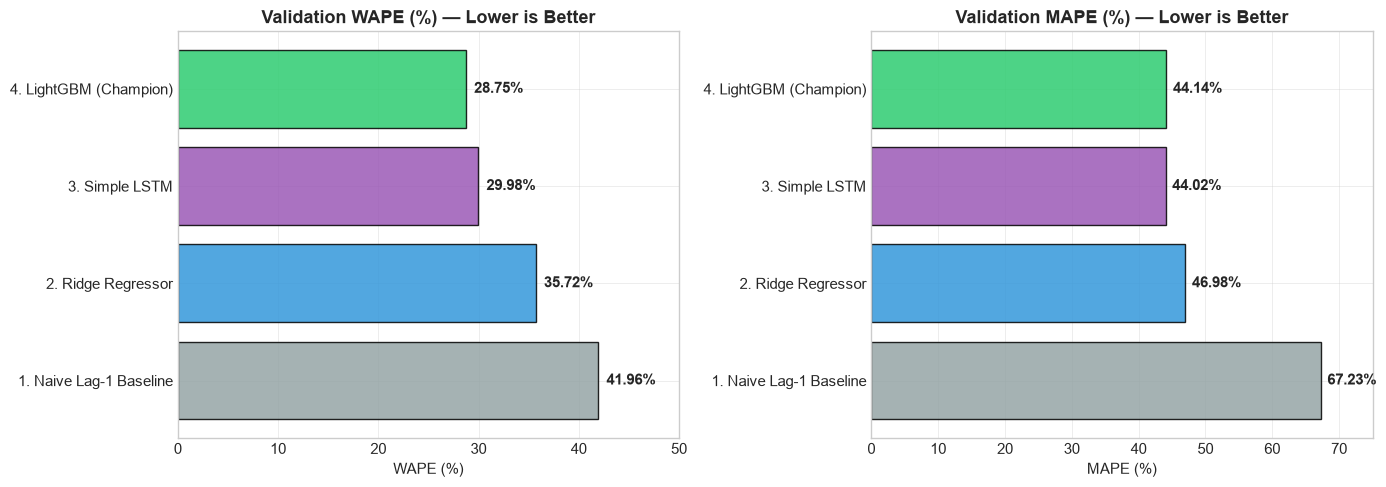

In [2]:
# Benchmark results from model_training.ipynb
models = ['1. Naive Lag-1 Baseline', '2. Ridge Regressor', '3. Simple LSTM', '4. LightGBM (Champion)']
wape_scores = [41.96, 35.72, 29.98, 28.75]
mape_scores = [67.23, 46.98, 44.02, 44.14]

benchmark_df = pd.DataFrame({
    'Model': models,
    'Validation WAPE (%)': wape_scores,
    'Validation MAPE (%)': mape_scores
})

print("=== FINAL MODEL BENCHMARK SCOREBOARD (Validation Weeks 132-145) ===")
print(benchmark_df.to_string(index=False))

# Visualization
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#95a5a6', '#3498db', '#9b59b6', '#2ecc71']

# WAPE Bar Chart
bars1 = ax[0].barh(models, wape_scores, color=colors, edgecolor='black', alpha=0.85)
ax[0].set_title('Validation WAPE (%) — Lower is Better', fontsize=13, fontweight='bold')
ax[0].set_xlabel('WAPE (%)')
ax[0].set_xlim(0, 50)
for bar in bars1:
    w = bar.get_width()
    ax[0].text(w + 0.8, bar.get_y() + bar.get_height()/2, f'{w:.2f}%', va='center', fontweight='bold')

# MAPE Bar Chart
bars2 = ax[1].barh(models, mape_scores, color=colors, edgecolor='black', alpha=0.85)
ax[1].set_title('Validation MAPE (%) — Lower is Better', fontsize=13, fontweight='bold')
ax[1].set_xlabel('MAPE (%)')
ax[1].set_xlim(0, 75)
for bar in bars2:
    w = bar.get_width()
    ax[1].text(w + 1.0, bar.get_y() + bar.get_height()/2, f'{w:.2f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.show()


## 2. Understanding `test.csv` & The Autoregressive Multi-Step Challenge

The raw test dataset (`DemandOps/data/raw/test.csv`) contains:
- **32,573 rows** covering **10 future weeks (weeks 146 to 155)** across 77 fulfillment centers and 51 meals.
- Known features available at order time: `checkout_price`, `base_price`, `emailer_for_promotion`, `homepage_featured`.
- **Missing components:**
  1. Static metadata (`category`, `cuisine`, `center_type`, `op_area`) which must be joined from info tables.
  2. Dynamic temporal features (`lag_1`, `lag_2`, `lag_4`, `rolling_mean_4`, `rolling_std_4`).

### Why One-Shot Prediction Fails:
- For **week 146**: `lag_1` is week 145 (available in historical data).
- For **week 147**: `lag_1` is week 146 — which has not happened yet!
- For **week 148**: `lag_1` is week 147 and `lag_2` is week 146.

### The Solution: Autoregressive Roll-Forward Forecasting
We maintain a continuous historical state lookup `{(center_id, meal_id, week): log_orders}`.
For each week from 146 to 155:
1. Extract dynamic lags and rolling aggregates from the lookup table.
2. Predict log demand using the LightGBM model bundle.
3. Invert the prediction to raw orders: $\hat{y} = \max(0, \exp(\hat{y}_{\log}) - 1)$.
4. **Feed $\hat{y}_{\log}$ back into the lookup dictionary for week $w$**, enabling future weeks to use it as their lag!


In [3]:
# 1. Load Trained LightGBM Model Bundle
bundle_path = "../models/lgb_model_bundle.joblib"
assert os.path.exists(bundle_path), f"Model bundle not found at {bundle_path}"

bundle = joblib.load(bundle_path)
model = bundle['model']
feature_cols = bundle['features']
cat_cols = bundle['cat_cols']

print(f"Loaded LightGBM model bundle successfully.")
print(f"Features ({len(feature_cols)}): {feature_cols}")
print(f"Categoricals ({len(cat_cols)}): {cat_cols}")

# 2. Load Raw Test Data & Metadata
test_raw = pd.read_csv("../data/raw/test.csv")
center_info = pd.read_csv("../data/raw/fulfilment_center_info.csv")
meal_info = pd.read_csv("../data/raw/meal_info.csv")

print(f"Test raw shape: {test_raw.shape}")
print(f"Test weeks: {test_raw['week'].min()} to {test_raw['week'].max()} ({test_raw['week'].nunique()} weeks)")

# 3. Merge Static Metadata
test_merged = test_raw.merge(center_info, on="center_id", how="left")
test_merged = test_merged.merge(meal_info, on="meal_id", how="left")

# 4. Static Feature Engineering
test_merged['price_change_pct'] = (test_merged['checkout_price'] - test_merged['base_price']) / test_merged['base_price']
test_merged['week_of_year'] = ((test_merged['week'] - 1) % 52) + 1

# 5. Initialize Historical Order State from processed_data.csv (Weeks 1 to 145)
print("Loading historical series for lag initialization...")
hist_df = pd.read_csv("../data/processed/processed_data.csv", usecols=['center_id', 'meal_id', 'week', 'log_num_orders'])

# Build in-memory lookup dictionary: (center_id, meal_id, week) -> log_num_orders
state_lookup = {(row.center_id, row.meal_id, row.week): row.log_num_orders for row in hist_df.itertuples()}
print(f"Historical state initialized with {len(state_lookup):,} (center, meal, week) records.")


Loaded LightGBM model bundle successfully.
Features (17): ['checkout_price', 'base_price', 'price_change_pct', 'lag_1', 'lag_2', 'lag_4', 'rolling_mean_4', 'rolling_std_4', 'op_area', 'week_of_year', 'emailer_for_promotion', 'homepage_featured', 'category', 'cuisine', 'center_type', 'center_id', 'meal_id']
Categoricals (5): ['category', 'cuisine', 'center_type', 'center_id', 'meal_id']
Test raw shape: (32573, 8)
Test weeks: 146 to 155 (10 weeks)
Loading historical series for lag initialization...
Historical state initialized with 521,565 (center, meal, week) records.


## 3. Autoregressive Roll-Forward Forecasting Engine

We now iterate through weeks 146 to 155 sequentially. In each step:
- Dynamic lags and 4-week rolling window statistics are computed from `state_lookup`.
- The LightGBM model predicts `pred_log = model.predict(X)`.
- Orders are unscaled via `np.expm1()` and clipped at 0.
- Predictions are written back to `state_lookup[(center, meal, week)] = pred_log` so subsequent weeks consume them automatically.


In [4]:
test_weeks = sorted(test_merged['week'].unique())
predictions_list = []

print("Starting Autoregressive Roll-Forward Multi-Step Forecasting (Weeks 146-155)...\n")
start_time = time.time()

for w in test_weeks:
    w_df = test_merged[test_merged['week'] == w].copy()
    
    # Extract dynamic lags from state lookup
    l1_list, l2_list, l4_list = [], [], []
    rm4_list, rs4_list = [], []
    
    for c, m in zip(w_df['center_id'], w_df['meal_id']):
        l1 = state_lookup.get((c, m, w - 1), 0.0)
        l2 = state_lookup.get((c, m, w - 2), 0.0)
        l3 = state_lookup.get((c, m, w - 3), 0.0)
        l4 = state_lookup.get((c, m, w - 4), 0.0)
        
        l1_list.append(l1)
        l2_list.append(l2)
        l4_list.append(l4)
        
        window = [l1, l2, l3, l4]
        rm4_list.append(float(np.mean(window)))
        rs4_list.append(float(np.std(window, ddof=1)))
        
    w_df['lag_1'] = l1_list
    w_df['lag_2'] = l2_list
    w_df['lag_4'] = l4_list
    w_df['rolling_mean_4'] = rm4_list
    w_df['rolling_std_4'] = rs4_list
    
    # Format features matching LightGBM contract
    X_w = w_df[feature_cols].copy()
    for col in cat_cols:
        X_w[col] = X_w[col].astype('category')
        
    # Predict log demand
    pred_log = model.predict(X_w)
    
    # Invert to raw order count and clip at 0
    pred_orders = np.clip(np.expm1(pred_log), 0, None)
    
    w_df['pred_log_orders'] = pred_log
    w_df['num_orders'] = pred_orders
    predictions_list.append(w_df)
    
    # Feed predictions back into state lookup for future weeks
    for c, m, pl in zip(w_df['center_id'], w_df['meal_id'], pred_log):
        state_lookup[(c, m, w)] = pl
        
    print(f"Week {w} Completed | Rows: {len(w_df):,} | Mean Demand: {pred_orders.mean():.1f} | Total Orders: {pred_orders.sum():,.0f}")

test_predictions = pd.concat(predictions_list, ignore_index=True)
elapsed = time.time() - start_time
print(f"\nAutoregressive forecasting complete in {elapsed:.2f} seconds.")


Starting Autoregressive Roll-Forward Multi-Step Forecasting (Weeks 146-155)...

Week 146 Completed | Rows: 3,240 | Mean Demand: 196.0 | Total Orders: 635,131
Week 147 Completed | Rows: 3,271 | Mean Demand: 216.0 | Total Orders: 706,546
Week 148 Completed | Rows: 3,332 | Mean Demand: 198.1 | Total Orders: 660,206
Week 149 Completed | Rows: 3,313 | Mean Demand: 197.0 | Total Orders: 652,792
Week 150 Completed | Rows: 3,277 | Mean Demand: 235.0 | Total Orders: 770,031
Week 151 Completed | Rows: 3,224 | Mean Demand: 224.4 | Total Orders: 723,310
Week 152 Completed | Rows: 3,242 | Mean Demand: 259.3 | Total Orders: 840,592
Week 153 Completed | Rows: 3,268 | Mean Demand: 238.3 | Total Orders: 778,705
Week 154 Completed | Rows: 3,228 | Mean Demand: 227.1 | Total Orders: 733,227
Week 155 Completed | Rows: 3,178 | Mean Demand: 196.5 | Total Orders: 624,576

Autoregressive forecasting complete in 1.52 seconds.


## 4. Prediction Sanity Checks & Quality Audits

Before finalizing predictions, we perform essential operational audits:
1. **Dimension Audit:** Ensure row count exactly matches the 32,573 rows expected in `test.csv`.
2. **Missing Value Audit:** Verify zero nulls or NaNs in predicted orders.
3. **Distribution Audit:** Compare predicted order statistics (mean, median, IQR, maximums) against historical training orders to verify no explosive or vanishing predictions.


In [5]:
# 1. Dimension & Null Checks
assert len(test_predictions) == 32573, f"Row mismatch: expected 32573, got {len(test_predictions)}"
assert test_predictions['num_orders'].isna().sum() == 0, "Null values detected in predictions!"
assert (test_predictions['num_orders'] < 0).sum() == 0, "Negative order predictions detected!"

print("✓ Dimension Check Passed: Exactly 32,573 test rows predicted.")
print("✓ Integrity Check Passed: 0 nulls, 0 negative values.")

# 2. Compare Test Predictions vs Historical Orders
train_raw = pd.read_csv("../data/raw/train.csv", usecols=['num_orders'])

comparison_stats = pd.DataFrame({
    'Train Historical Orders': train_raw['num_orders'].describe(),
    'Test Predicted Orders': test_predictions['num_orders'].describe()
}).round(2)

print("\n=== DISTRIBUTION SUMMARY COMPARISON ===")
print(comparison_stats)


✓ Dimension Check Passed: Exactly 32,573 test rows predicted.
✓ Integrity Check Passed: 0 nulls, 0 negative values.

=== DISTRIBUTION SUMMARY COMPARISON ===
       Train Historical Orders  Test Predicted Orders
count                456548.00               32573.00
mean                    261.87                 218.74
std                     395.92                 296.30
min                      13.00                   0.00
25%                      54.00                  46.11
50%                     136.00                 119.04
75%                     324.00                 271.05
max                   24299.00                3613.86


### Visualizing Forecast Health & Aggregate Trends


(array([5.42670879e-01, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        5.06053332e-01, 0.00000000e+00, 0.00000000e+00, 4.49365140e-01,
        0.00000000e+00, 3.83955687e-01, 3.34814175e-01, 2.93703857e-01,
        2.58554535e-01, 2.29806677e-01, 2.08678910e-01, 3.66043335e-01,
        2.16504553e-01, 3.80872413e-01, 2.42653652e-01, 3.11851126e-01,
        2.68274189e-01, 2.93615764e-01, 2.53591933e-01, 2.52461399e-01,
        1.91603446e-01, 1.67113442e-01, 1.34151777e-01, 1.05712246e-01,
        8.45697969e-02, 6.23114962e-02, 4.67189399e-02, 3.48703590e-02,
        2.66482954e-02, 1.83381383e-02, 1.25239647e-02, 8.48634420e-03,
        5.52052841e-03, 4.09634954e-03, 2.36384328e-03, 1.60036595e-03,
        1.10116923e-03, 8.66253128e-04, 4.40467692e-04, 3.23009641e-04,
        1.90869333e-04, 7.34112820e-05, 4.40467692e-05, 0.00000000e+00,
        0.00000000e+00, 1.46822564e-05]),
 array([ 2.63905733,  2.78824082,  2.9374243 ,  3.08660779,  3.23579127,
         3.38497476, 

(array([0.02473166, 0.00655764, 0.0033725 , 0.00449667, 0.00393458,
        0.00412194, 0.00487139, 0.00599556, 0.00693236, 0.00655764,
        0.01030486, 0.01704986, 0.01948555, 0.02248333, 0.03990791,
        0.08206416, 0.10510958, 0.10998096, 0.13040332, 0.15513499,
        0.18979679, 0.20534776, 0.23719915, 0.23926012, 0.22146082,
        0.23851068, 0.27129887, 0.28010484, 0.321699  , 0.35654817,
        0.29846623, 0.3106447 , 0.29884095, 0.28310262, 0.29228331,
        0.23457609, 0.23420137, 0.20384887, 0.16394096, 0.11054305,
        0.09311847, 0.07419499, 0.05246111, 0.0380343 , 0.03278819,
        0.02698   , 0.01667514, 0.00843125, 0.00374722, 0.00131153]),
 array([0.        , 0.16385618, 0.32771236, 0.49156853, 0.65542471,
        0.81928089, 0.98313707, 1.14699325, 1.31084942, 1.4747056 ,
        1.63856178, 1.80241796, 1.96627414, 2.13013031, 2.29398649,
        2.45784267, 2.62169885, 2.78555503, 2.9494112 , 3.11326738,
        3.27712356, 3.44097974, 3.60483592, 3.

Text(0.5, 1.0, 'Log-Demand Distribution: Train Actuals vs Test Predictions')

Text(0.5, 0, 'log(1 + num_orders)')

Text(0, 0.5, 'Density')

Text(0.5, 1.0, 'Total Platform Weekly Demand: Transition into Test Horizon')

Text(0.5, 0, 'Week Number')

Text(0, 0.5, 'Total Platform Orders')

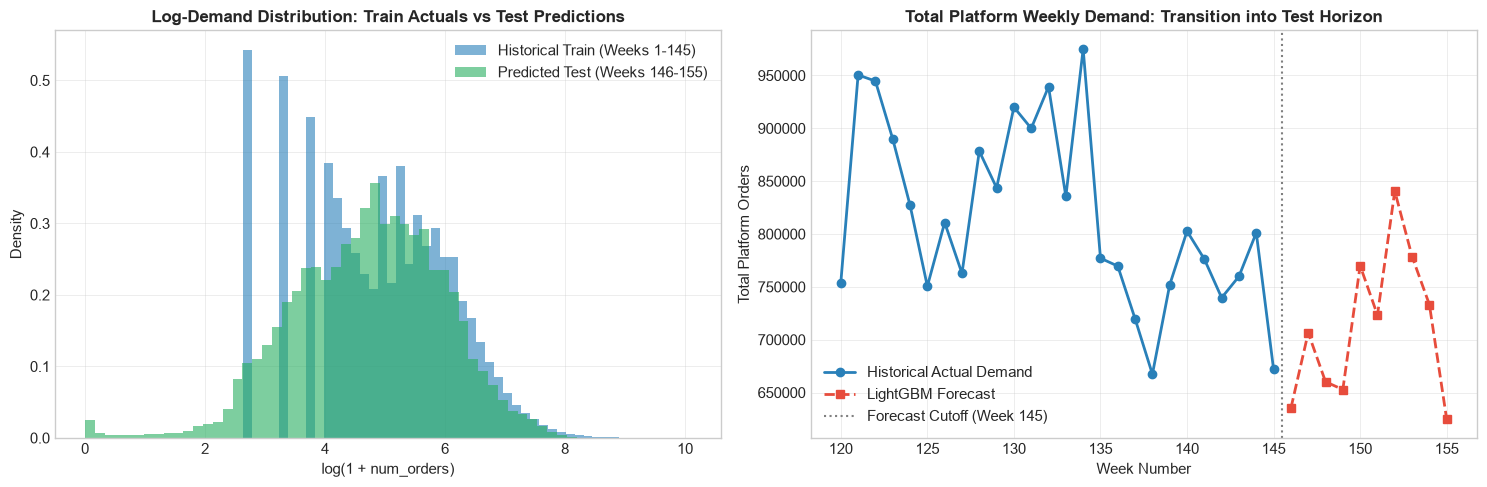

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Subplot 1: Distribution Comparison (Log scale)
axes[0].hist(np.log1p(train_raw['num_orders']), bins=50, alpha=0.6, label='Historical Train (Weeks 1-145)', density=True, color='#2980b9')
axes[0].hist(np.log1p(test_predictions['num_orders']), bins=50, alpha=0.6, label='Predicted Test (Weeks 146-155)', density=True, color='#27ae60')
axes[0].set_title('Log-Demand Distribution: Train Actuals vs Test Predictions', fontsize=12, fontweight='bold')
axes[0].set_xlabel('log(1 + num_orders)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Subplot 2: Platform Total Weekly Demand Trend
train_weekly = pd.read_csv("../data/raw/train.csv").groupby('week')['num_orders'].sum().reset_index()
test_weekly = test_predictions.groupby('week')['num_orders'].sum().reset_index()

# Focus on last 25 historical weeks + 10 test weeks
recent_train_weekly = train_weekly[train_weekly['week'] >= 120]

axes[1].plot(recent_train_weekly['week'], recent_train_weekly['num_orders'], marker='o', label='Historical Actual Demand', color='#2980b9', linewidth=2)
axes[1].plot(test_weekly['week'], test_weekly['num_orders'], marker='s', linestyle='--', label='LightGBM Forecast', color='#e74c3c', linewidth=2)
axes[1].axvline(x=145.5, color='gray', linestyle=':', label='Forecast Cutoff (Week 145)')
axes[1].set_title('Total Platform Weekly Demand: Transition into Test Horizon', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Week Number')
axes[1].set_ylabel('Total Platform Orders')
axes[1].legend()

plt.tight_layout()
plt.show()


## 5. Export Final Competition & Production Submission

We assemble the final submission dataframe containing:
- `id`: The unique order identifier matching `test.csv`.
- `num_orders`: The model's forecasted demand.

The output is saved to `DemandOps/data/processed/submission_lgb.csv`.


In [7]:
submission_df = test_predictions[['id', 'num_orders']].copy()

# Sort by id to ensure exact alignment
submission_df = submission_df.sort_values('id').reset_index(drop=True)

output_path = "../data/processed/submission_lgb.csv"
submission_df.to_csv(output_path, index=False)

print(f"Final submission successfully exported to: {os.path.abspath(output_path)}")
print(f"File size: {os.path.getsize(output_path) / 1024:.2f} KB")
print(f"Shape: {submission_df.shape}")
print("\nFirst 10 submission rows:")
print(submission_df.head(10))


Final submission successfully exported to: /Users/iamnitishsah/Documents/Projects/FoodOps.AI/DemandOps/data/processed/submission_lgb.csv
File size: 839.15 KB
Shape: (32573, 2)

First 10 submission rows:
        id  num_orders
0  1000085   83.308777
1  1000100  185.090960
2  1000105  386.546926
3  1000116  191.680456
4  1000119  115.478351
5  1000121   50.526697
6  1000127  382.641282
7  1000162   19.895473
8  1000164  717.523887
9  1000187   73.367011
